# 2D affine — advanced explicit grid (silicon)

This is the **advanced** path when you want fixed, reproducible controls.
It uses the same raw pair as the automatic silicon tutorial. You set:

1. `preprocess(...)` — padding, smoothing, normalization, and `downsample=1`  
2. `correct_affine(max_drift_rate=..., num_rates=...)` — fixed native-resolution grid  

Explicit affine grids are evaluated at full resolution; they do not use the
automatic solver's binned broad-search pyramid.

Use this for a reproducible search recipe or to override automatic search.
For day-to-day work, start with the automated notebook and come here for more control.

## Device and paths

In [1]:
from pathlib import Path

import quantem.widget as qw
from quantem.imaging import DriftCorrection

# Same raw data as the matching automated tutorial (relative to advanced/).
DATA = Path("../data/silicon")
RESULT = DATA / "drift_explicit.zip"  # do not overwrite automated drift.zip

# Interactive is the recommended default. False uses static/report rendering.
INTERACTIVE = True
VIEW_MODE = "interactive" if INTERACTIVE else "static"

qw.profile()

quantem.widget  0.0.1rc36
  install       published package
quantem.gpu     0.0.1rc6
  install       editable checkout
quantem         0.1.9
torch           2.13.0  device=cuda (NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition)
GPUs            1 visible (CUDA_VISIBLE_DEVICES=1)
  GPU0           23.5 used / 102 GB  (78 free)
  torch pool    0.0 live / 0.0 reserved GB
python          3.14.6


## Load

In [2]:
drift = DriftCorrection.from_emd(
    DATA / "0041_20260515_1130_15.0_Mx_6.74_nm_Nano_HAADF.emd",
    DATA / "0042_20260515_1130_15.0_Mx_6.74_nm_Nano_HAADF.emd",
    verbose=False,
)

## Preprocess (explicit)

Call this yourself in the advanced path so the canvas is fixed before the grid
search. The automated tutorial lets `correct_affine()` prepare automatically.

In [3]:
drift.preprocess(
    padding_fraction=0.25,
    smoothing_sigma=0.5,
    num_knots=1,
    normalize=False,
    downsample=1,  # preserve every acquired pixel
    verbose=True,
    show_combined=False,
    show_scans=False,
    show_knots=False,
)

## Affine on an explicit candidate grid

`max_drift_rate` and `num_rates` fix the full-resolution candidate grid.
The ±0.25 px/line range covers the large silicon drift as well as the smaller
Co₃O₄ and SrTiO₃ drifts. The 41-point axis grid plus refinement reproduces the
paper registrations without binning.

In [4]:
drift.correct_affine(
    # --- explicit grid (both required for non-automatic search) ---
    max_drift_rate=0.25,  # px/scanline; search each axis in [-r, +r]
    num_rates=41,         # odd; includes zero and both endpoints
    refine=True,          # finer search around the coarse winner
    max_image_shift=512,
    # Explicit grids are always native resolution; downsample is automatic-mode only.
    # chunk_size=None,    # batch size for candidates; None = all at once
    # fixed_scans=None,   # e.g. [0] to freeze scan 0
    # --- display during solve ---
    show_combined=False,  # RGB merge when this cell finishes
    show_scans=False,     # each warped scan
    show_knots=False,     # knot overlay on those plots
    show_knot_plot=False, # separate knot trajectory figure
    show_report=False,    # NCC table here (report() cell below)
    verbose=True,         # top candidates — useful when tuning the grid
)

Affine coarse search:   0%|          | 0/1313 [00:00<?, ?candidate/s]

Affine coarse search:   0%|          | 0/1313 [00:00<?, ?candidate/s]

Affine coarse search:   3%|▎         | 37/1313 [00:00<00:10, 125.06candidate/s]

  affine grid: 1313 drift vectors × 2560×2560, auto chunk 54/chunk × 25 passes (47/102 GB free)


Affine coarse search:   7%|▋         | 91/1313 [00:00<00:07, 165.01candidate/s]

...

Affine refine search:  97%|█████████▋| 1274/1313 [00:07<00:00, 153.76candidate/s]

Affine refine search:  99%|█████████▉| 1297/1313 [00:07<00:00, 153.74candidate/s]

Affine refine search: 100%|██████████| 1313/1313 [00:08<00:00, 78.27candidate/s] 

Affine refine search: 100%|██████████| 1313/1313 [00:08<00:00, 154.41candidate/s]

  Refine search - top 5 candidates:
    drift=(+0.0028, +0.0009) px/line (0.0030 magnitude), cost=307.0632 (best)
    drift=(+0.0025, +0.0006) px/line (0.0026 magnitude), cost=307.0958 (+0.0%)
    drift=(+0.0028, +0.0013) px/line (0.0031 magnitude), cost=307.1002 (+0.0%)
    drift=(+0.0025, +0.0009) px/line (0.0027 magnitude), cost=307.1043 (+0.0%)
    drift=(+0.0028, +0.0016) px/line (0.0032 magnitude), cost=307.1129 (+0.0%)
correct_affine: max_drift_rate=0.25, num_rates=41 per axis; 1313 drift vectors evaluated; refine=True, max_image_shift=512
Drift: (-0.0722, +0.1384) px/line, 0.1561 magnitude, 117.5°, 319.8 px total over 2048 lines = 1.05 nm
Error: 241.23 -> 153.41 (+36.4%)
Confidence: 0.0% cost margin to runner-up (low)


## Check registration — `plot_combined`

Same knobs as the automated tutorial.

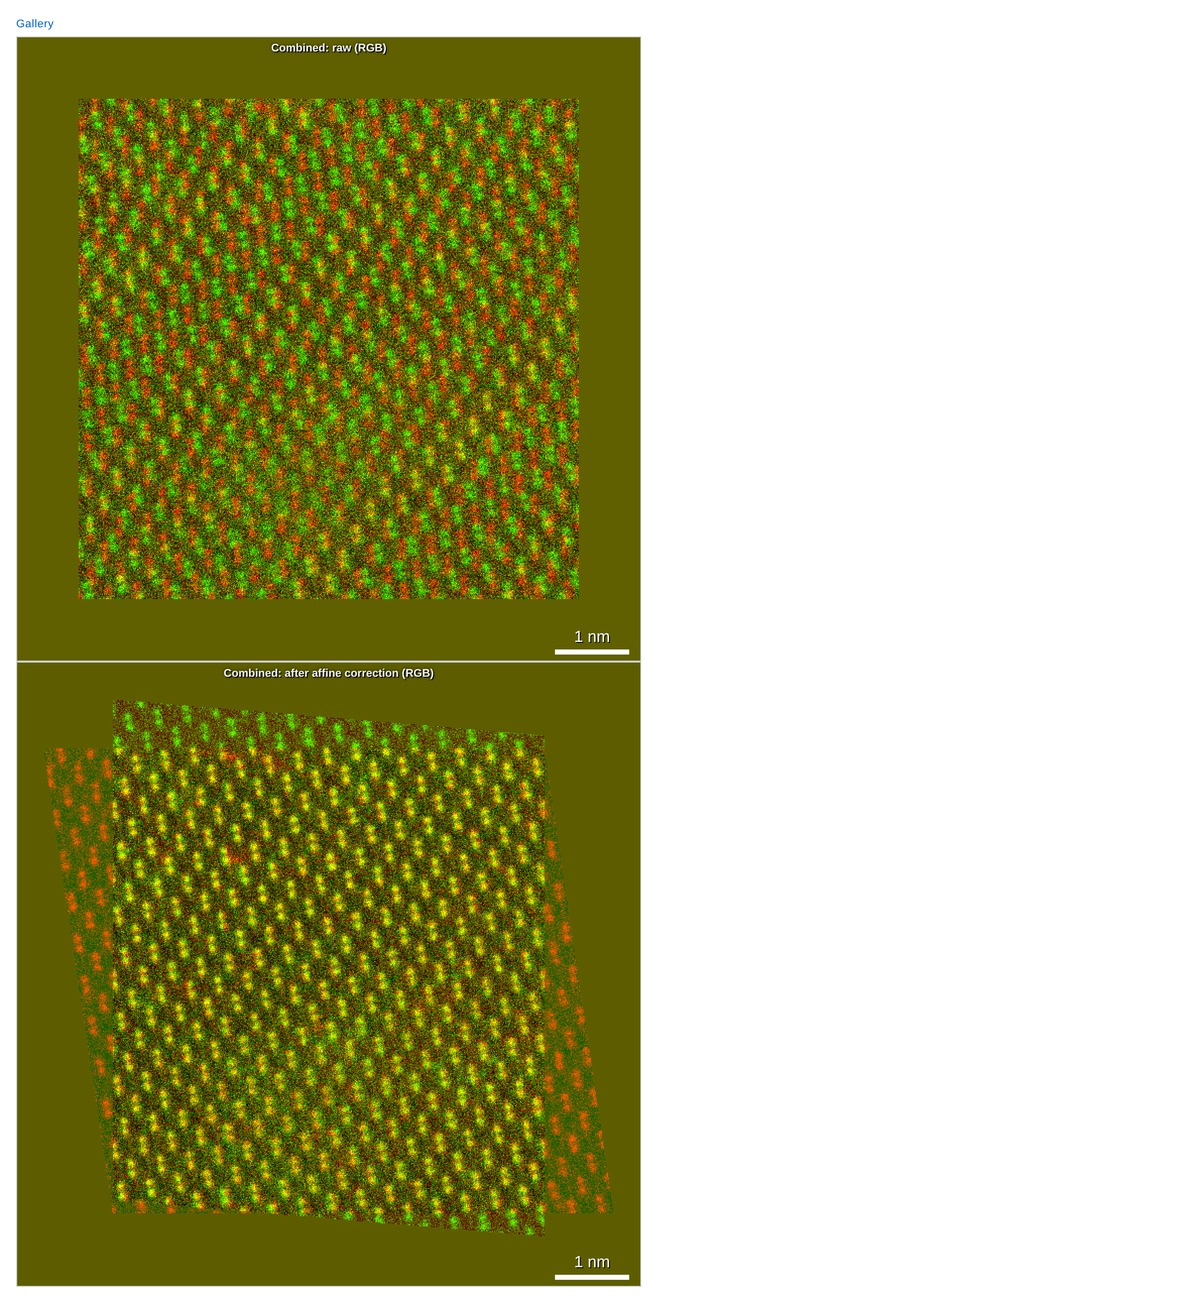

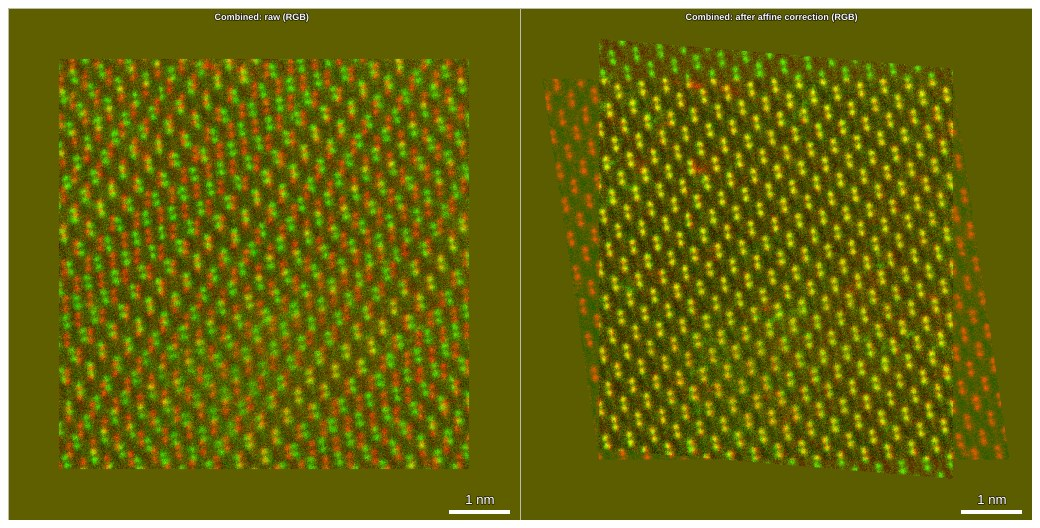

In [5]:
drift.plot_combined(
    stage=("initial", "affine"),  # before | after
    interactive=INTERACTIVE,      # linked widget | static Matplotlib
    width=620,                    # panel width px — 400 | 620 | 900
    # show_fft=False,             # FFT under each panel
    # zoom=1.0,
    # center=(0.0, 0.0),
)

In [6]:
drift.report()

,Common NCC,Top third,Middle third,Bottom third,Coverage
Mutual stage,,,,,
before,-0.000288,0.001638,-0.000289,-0.002632,0.795289
affine,0.394574,0.421364,0.401800,0.358701,0.795289


## Corrected result — `show()`

  Display bin 3×: 2560×2560 → 853×853 (16 MB preview; full-res detail streams on zoom)


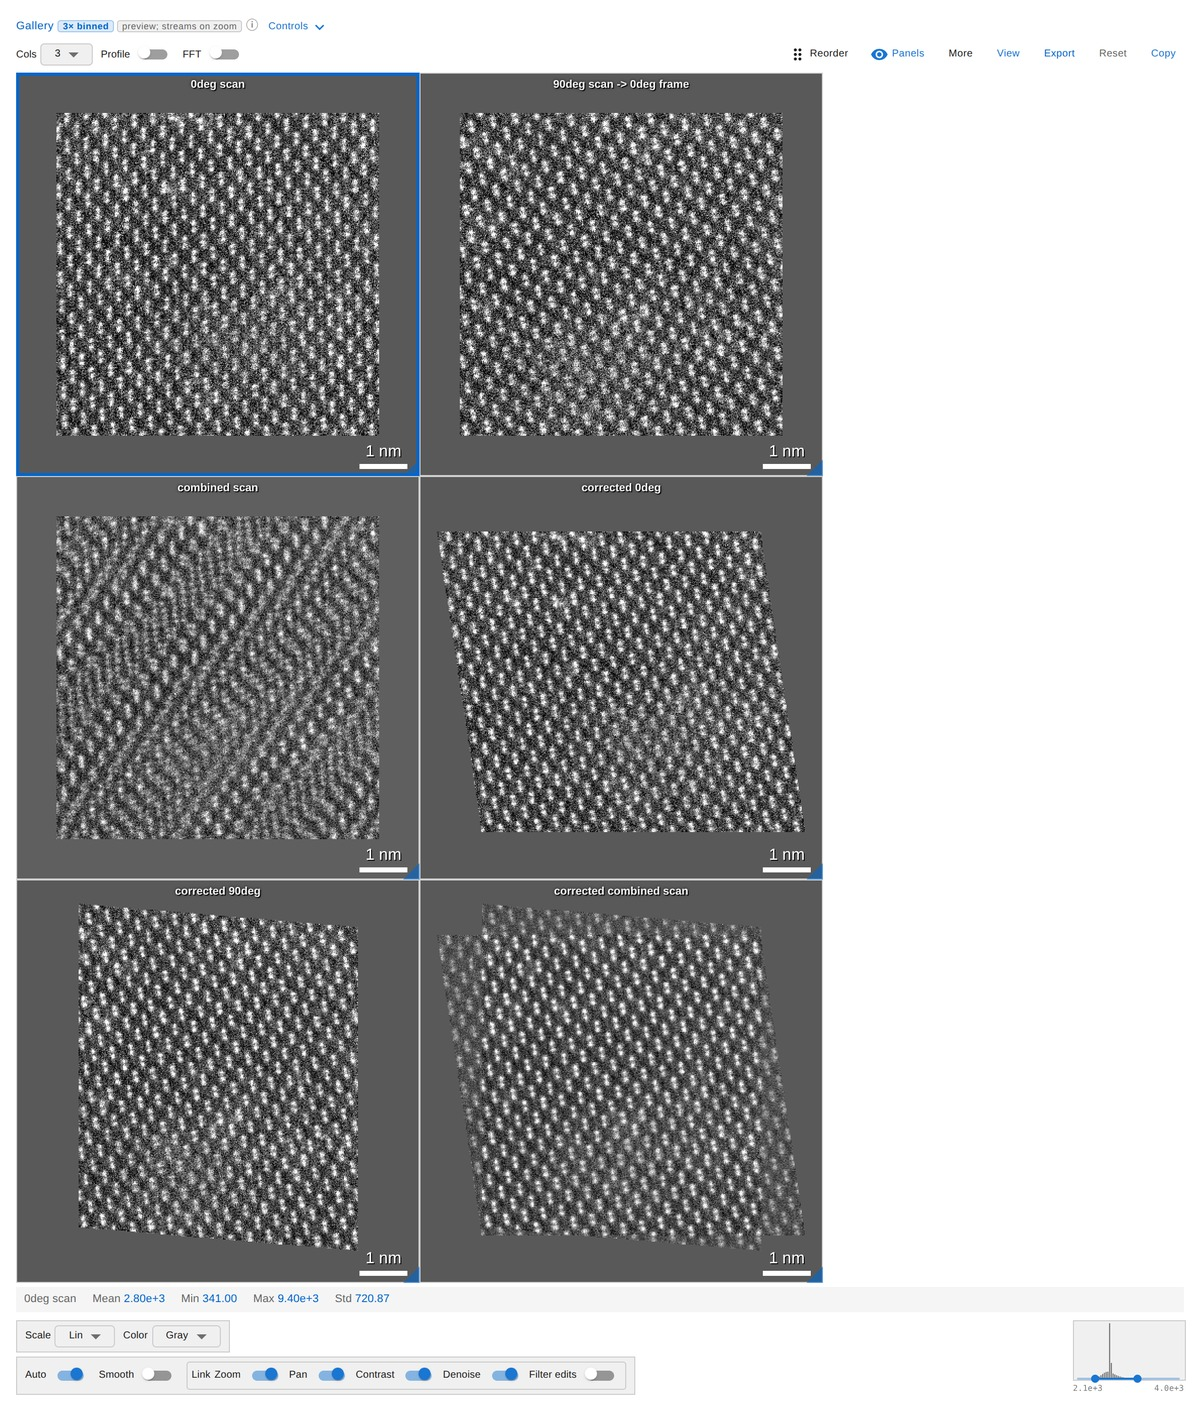

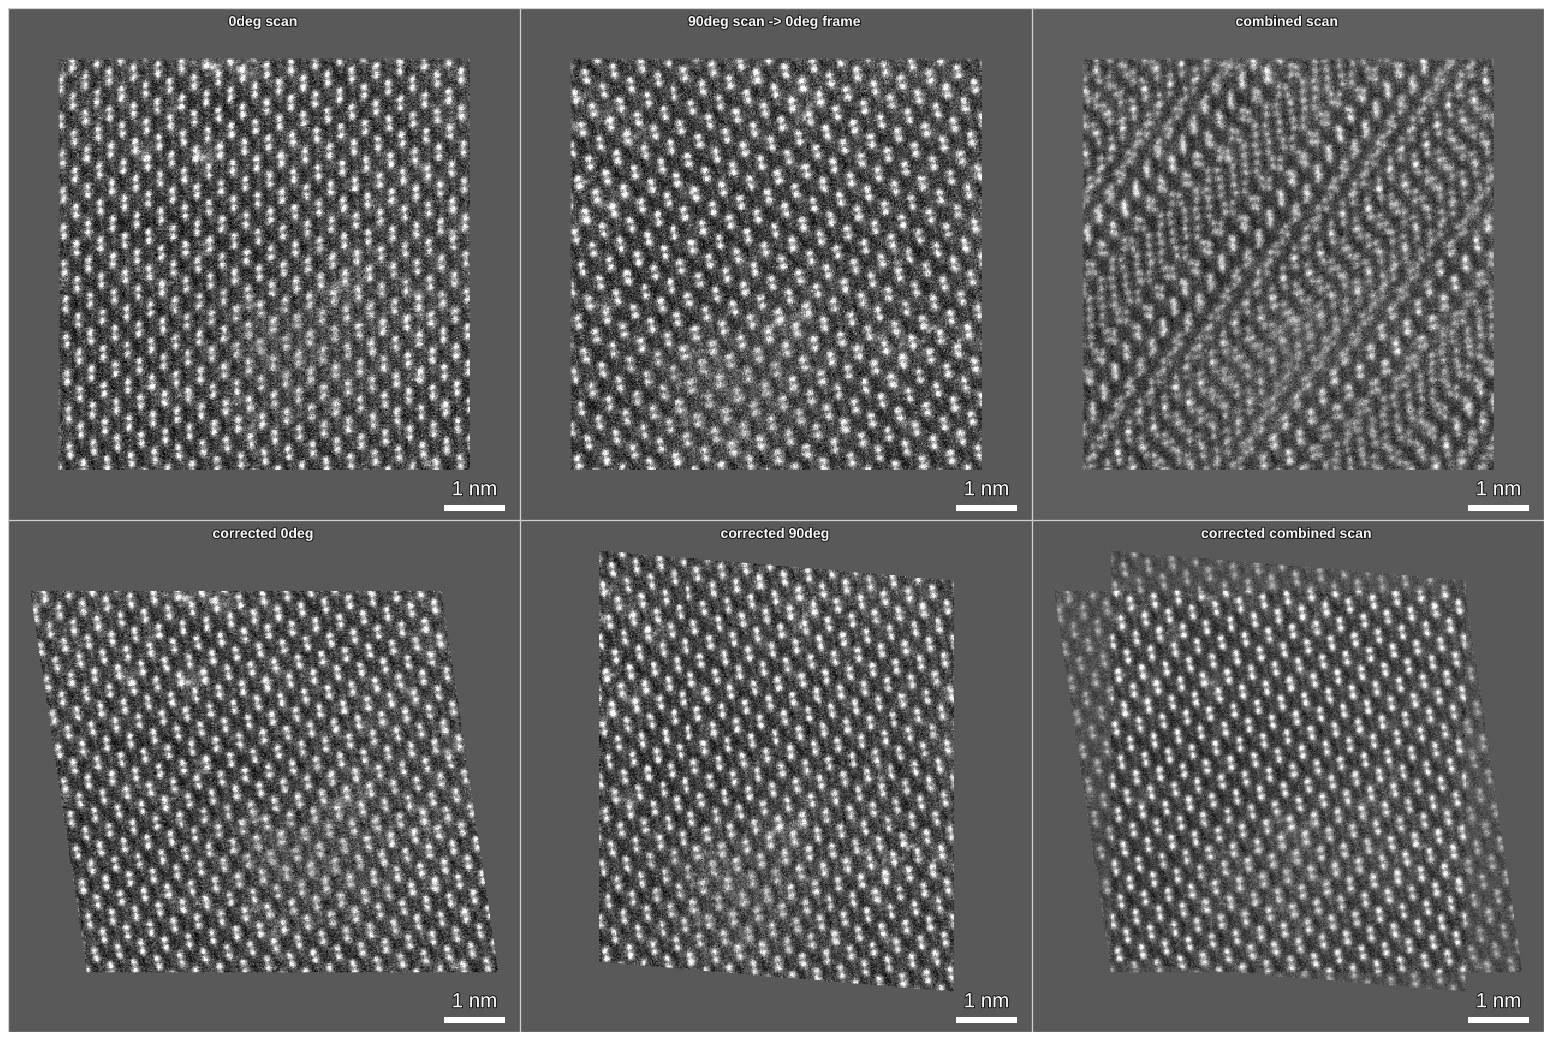

In [7]:
drift.show(
    mode=VIEW_MODE,
    cmap="gray",           # gray | inferno | viridis
    auto_contrast=True,    # percentile clim | full range
    link_contrast=True,    # shared clim across panels
    smooth=False,          # nearest | interpolated
    show_fft=False,        # FFT companion panels
    # zoom=1.0,
    # size=400,
)

## Save (separate zip from the automated tutorial)

In [8]:
DATA.mkdir(parents=True, exist_ok=True)
drift.save(RESULT, mode="o")
print(f"Saved: {RESULT}")

Saved: ../data/silicon/drift_explicit.zip


## Compare to automated

| | Automated tutorial | This notebook |
|--|--|--|
| Preprocess | inside automatic `correct_affine` | explicit `preprocess(...)` |
| Search | automatic pyramid | fixed native-resolution grid |
| Output zip | `drift.zip` | `drift_explicit.zip` |

Regenerate:

```bash
python tutorials/template/build_2d_affine_explicit_tutorial.py
```